# Mini Projeto 01
### Análise de Vendas para Loja de Ecommerce com Numpy, Pandas e Matplotlib

---

## 1 - Definição do Problema de Negócio

#### 1.1 - O Problema de Negócio

Nossa loga de ecommerce esta em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, más não conseguimos acessá-lo.

Atualmente, muitas das nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

* Gestão de Estoque Ineficiente: Não temos clareza sobre produtos são os nossos "campeões de vendas" e quais estão parados nas prateleiras. Isso resulta em exceço de estoque de itens de baixa procura e falta de produtos de alta demanda.

* Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

* Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendencias de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

* Expansão sem Direção: Temos o desejo de expandir, más não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

#### 1.2 - Objetivos do Projeto

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

* O que vender? Identificar os produtos de maior sucesso para otimizar o nosso portfólio e estoque.

* Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

* Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

* Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir os nossos mercados mais fortes.

#### 1.3 - Solução Proposta

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (Python, Pandas, Numpy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

#### 1.4 - Resultados Esperados

Ao fnal deste projeto, esperamos alcançar os seguintes resultados:

* Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, podemos ajustar nossas comprar, reduzir custos com armazenamento e evitar a perda de venda por falta de produto.

* Marketing Direciona e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno do investimento (ROI).

* Planejamento Estratégico: A visualiação das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

* Decisões Baseadas em Dados: Substituiremos a intuição or dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.


















---

## 2 - Importação das Bibliotecas

In [1]:
# instalacao do pacote watermark
!pip install -q -U watermark

In [2]:
# importacao da biblioteca para manipulacao de dados em tabela
import pandas as pd

# importacao da biblioteca matematica para operacoes matematicas e arrays
import numpy as np

# importacao da biblioteca para geracao de graficos
import matplotlib.pyplot as plt

# importacao da biblioteca para a visualizacao estatistica de dados
import seaborn as sns

# importação da biblioteca para geracao de numeros aleatorios
import random

# importacao da biblioteca para manipulacao de data e intervalos de tempo
from datetime import datetime, timedelta

In [3]:
# comando do jupyter notebook que permite exibir graficos diretamente no notebook
%matplotlib inline

In [4]:
# definicao do watermark
%reload_ext watermark
%watermark -a "Netmarvin"

Author: Netmarvin



In [5]:
# definicao das bibliotecas e versoes
%watermark --iversions

matplotlib: 3.10.9
numpy     : 2.4.4
pandas    : 3.0.2
seaborn   : 0.13.2



## 3 - Função para Geração de Dados Fictícios:

In [6]:
# definicao da funcao para gerar dados ficticios de vendas
def gerar_dados_ficticios(quantidade_registros=600):

  """
  Gera um DataFrame do Pandas com dados ficticios de vendas
  """

  print(f"\nIniciando a geração de {quantidade_registros} registros de vendas...")

  # dicionario com produtos, categorias e precos
  produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
  }

  # definicao de uma lista apenas com os nomes dos produtos
  lista_nomes_produtos = list(produtos.keys())

  # dicionario com cidades e seus respectivos estados
  cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
  }

  # definicao de uma lista apenas com os nomes das cidades
  lista_nomes_cidades = list(cidades_estados.keys())

  # definicao inicial da lista que armazenara os registros de vendas
  dados_vendas = []

  # define a data inicial dos pedidos
  data_inicial = datetime(2026, 1, 1)

  # loop para gerar os registros de vendas
  for i in range(quantidade_registros):

    # selecao aleatoria de um produto
    produto_nome = random.choice(lista_nomes_produtos)

    # selecao aleatoria de uma cidade
    cidade = random.choice(lista_nomes_cidades)

    # definicao de uma quantidae de produtos vendidos entre 1 e 7
    quantidade = random.randint(1, 8)

    # definicao da data do pedido a partir da data inicial
    data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

    # regra de negocio: se o produto for mouse ou teclado, aplica desconto aleatorio de ate 10%
    if produto_nome in ["Mouse Vertical", "Teclado Mecânico"]:
      preco_unitario = produtos[produto_nome]["preco"] * np.random.uniform(0.9, 1.0)
    else:
      preco_unitario = produtos[produto_nome]["preco"]

    # adiciona um registro de venda na lista
    dados_vendas.append({
        "id_pedido": 1000 + i,
        "data_pedido": data_pedido,
        "nome_produto": produto_nome,
        "categoria": produtos[produto_nome]["categoria"],
        "preco_unitario": round(preco_unitario, 2),
        "quantidade": quantidade,
        "id_cliente": np.random.randint(100, 150),
        "cidade": cidade,
        "estado": cidades_estados[cidade]
    })

  print("Geração de registros concluido\n")

  # retorna os dados no formato DataFrame do Pandas
  return pd.DataFrame(dados_vendas)

## 4 - Gerar, Carregar e Explorar os Dados

In [7]:
# geracao dos dados de vendas
df_vendas = gerar_dados_ficticios(500)


Iniciando a geração de 500 registros de vendas...
Geração de registros concluido



In [8]:
print(type(df_vendas))

<class 'pandas.DataFrame'>


In [9]:
df_vendas.shape

(500, 9)

In [10]:
# exibe as 5 primeiras linhas do dataframe
df_vendas.head()

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado
0,1000,2026-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,117,Fortaleza,CE
1,1001,2026-01-01 13:00:00,Headset 7.1,Acessórios,800.00,2,134,Rio de Janeiro,RJ
2,1002,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,499.21,1,147,Porto Alegre,RS
3,1003,2026-01-01 10:00:00,Cadeira Gamer,Móveis,1200.00,6,109,Curitiba,PR
4,1004,2026-01-01 23:00:00,Placa de Vídeo,Hardware,4500.00,8,129,Curitiba,PR


In [11]:
# exibe as 5 ultimas linhas do dataframe
df_vendas.tail()

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado
495,1495,2026-04-10 13:00:00,Teclado Mecânico,Acessórios,547.39,3,106,Rio de Janeiro,RJ
496,1496,2026-04-10 09:00:00,Placa de Vídeo,Hardware,4500.00,8,139,Fortaleza,CE
497,1497,2026-04-10 23:00:00,SSD 1TB,Hardware,600.00,6,141,Belo Horizonte,MG
498,1498,2026-04-10 00:00:00,Headset 7.1,Acessórios,800.00,3,108,Porto Alegre,RS
499,1499,2026-04-10 08:00:00,Teclado Mecânico,Acessórios,541.21,3,147,Belo Horizonte,MG


In [12]:
# exibe informacoes gerais do dataframe (nome das colunas, tipo de dados e nao nulos)
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_pedido       500 non-null    int64         
 1   data_pedido     500 non-null    datetime64[us]
 2   nome_produto    500 non-null    str           
 3   categoria       500 non-null    str           
 4   preco_unitario  500 non-null    float64       
 5   quantidade      500 non-null    int64         
 6   id_cliente      500 non-null    int64         
 7   cidade          500 non-null    str           
 8   estado          500 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 35.3 KB


In [13]:
# exibe resumo estatistico
df_vendas.describe()

,id_pedido,data_pedido,preco_unitario,quantidade,id_cliente
count,500.000000,500,500.000000,500.000000,500.000000
mean,1249.500000,2026-02-19 23:39:36,2436.519920,4.506000,123.318000
min,1000.000000,2026-01-01 10:00:00,225.150000,1.000000,100.000000
25%,1124.750000,2026-01-26 01:15:00,544.435000,3.000000,111.000000
50%,1249.500000,2026-02-19 23:30:00,1000.000000,4.000000,123.000000
75%,1374.250000,2026-03-16 19:00:00,4500.000000,6.000000,136.000000
max,1499.000000,2026-04-10 23:00:00,7500.000000,8.000000,149.000000
std,144.481833,NaN,2553.308463,2.277793,14.067148


In [14]:
# exibe tipo de dados
df_vendas.dtypes

id_pedido                  int64
data_pedido       datetime64[us]
nome_produto                 str
categoria                    str
preco_unitario           float64
quantidade                 int64
id_cliente                 int64
cidade                       str
estado                       str
dtype: object

## 5 - Limpeza, Pré-Processamento e Engenharia de Atributos

In [15]:
# se a coluna "data_pedido" nao estiver com o tipo datetime, precisamos fazer a conversao explicita
# observacao: esta coluna sera usada para analise temporal, por isto deve estar no formato datetime
df_vendas['data_pedido'] = pd.to_datetime(df_vendas['data_pedido'])

# exibe tipo de dados
df_vendas.dtypes

id_pedido                  int64
data_pedido       datetime64[us]
nome_produto                 str
categoria                    str
preco_unitario           float64
quantidade                 int64
id_cliente                 int64
cidade                       str
estado                       str
dtype: object

In [16]:
# engenharia de atributos
# criando a nova coluna "faturamento" (preco x quantidade)
df_vendas['faturamento'] = df_vendas['preco_unitario'] * df_vendas['quantidade']

In [17]:
# engenharia de atributos
# lista de estados com entrega rapida
estados_entrega_rapida = ['SP', 'RJ', 'MG', 'ES']

# usando a funcao lambda pra criar uma nova coluna "status_entrega"
df_vendas['status_entrega'] = df_vendas['estado'].apply(lambda estado: 'rapida' if estado in estados_entrega_rapida else 'normal')

In [18]:
# exibe informacoes gerais do dataframe (nome das colunas, tipo de dados e nao nulos)
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_pedido       500 non-null    int64         
 1   data_pedido     500 non-null    datetime64[us]
 2   nome_produto    500 non-null    str           
 3   categoria       500 non-null    str           
 4   preco_unitario  500 non-null    float64       
 5   quantidade      500 non-null    int64         
 6   id_cliente      500 non-null    int64         
 7   cidade          500 non-null    str           
 8   estado          500 non-null    str           
 9   faturamento     500 non-null    float64       
 10  status_entrega  500 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 43.1 KB


In [19]:
# Exibe as 10 primeiras linhas novamente para ver as novas colunas
df_vendas.head(10)

,id_pedido,data_pedido,nome_produto,categoria,preco_unitario,quantidade,id_cliente,cidade,estado,faturamento,status_entrega
0,1000,2026-01-01 12:00:00,Placa de Vídeo,Hardware,4500.00,3,117,Fortaleza,CE,13500.00,normal
1,1001,2026-01-01 13:00:00,Headset 7.1,Acessórios,800.00,2,134,Rio de Janeiro,RJ,1600.00,rapida
2,1002,2026-01-01 23:00:00,Teclado Mecânico,Acessórios,499.21,1,147,Porto Alegre,RS,499.21,normal
3,1003,2026-01-01 10:00:00,Cadeira Gamer,Móveis,1200.00,6,109,Curitiba,PR,7200.00,normal
4,1004,2026-01-01 23:00:00,Placa de Vídeo,Hardware,4500.00,8,129,Curitiba,PR,36000.00,normal
5,1005,2026-01-02 20:00:00,Monitor Ultrawide,Eletrônicos,2800.00,3,113,Rio de Janeiro,RJ,8400.00,rapida
6,1006,2026-01-02 02:00:00,SSD 1TB,Hardware,600.00,8,141,Porto Alegre,RS,4800.00,normal
7,1007,2026-01-02 08:00:00,Laptop Gamer,Eletrônicos,7500.00,1,110,Curitiba,PR,7500.00,normal
8,1008,2026-01-02 17:00:00,Teclado Mecânico,Acessórios,540.37,3,103,Curitiba,PR,1621.11,normal
9,1009,2026-01-02 21:00:00,Teclado Mecânico,Acessórios,505.76,5,126,São Paulo,SP,2528.80,rapida


In [20]:
# salva os dados de vendas (limpos, convertidos, sem nulos, organizados e processados)
df_vendas.to_csv("dados_vendas.csv", index=False)

## 6 - Análise 01 - Top 10 Produtos Mais Vendidos
Quais os top 10 produtos mais vendidos?

In [21]:
# agrupa por nome do produto, soma a quantidade e ordena a quantidade de forma 
# decrescente para encontrar os top 10 mais vendidos
top_10_produtos_mais_vendidos = df_vendas.groupby('nome_produto')['quantidade'].sum().sort_values(ascending=False).head(10)

# exibe o resultado
top_10_produtos_mais_vendidos

nome_produto
Laptop Gamer         353
Teclado Mecânico     335
Monitor Ultrawide    319
SSD 1TB              306
Mouse Vertical       247
Headset 7.1          240
Placa de Vídeo       233
Cadeira Gamer        220
Name: quantidade, dtype: int64

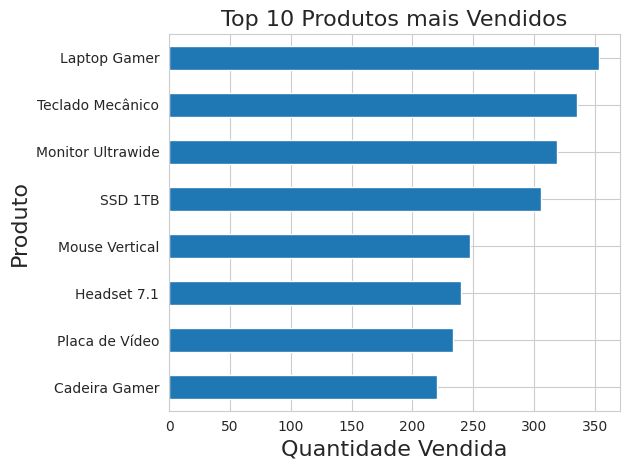

In [22]:
# define um estilo para o grafico
sns.set_style("whitegrid")

# define a figura e os eixos
plt.Figure(figsize=(12, 7))

# define grafico de barras horizontais
top_10_produtos_mais_vendidos.sort_values(ascending=True).plot(kind="barh")

# define titulo e labels
plt.title("Top 10 Produtos mais Vendidos", fontsize=16)
plt.xlabel("Quantidade Vendida", fontsize=16)
plt.ylabel("Produto", fontsize=16)

# exibe o grafico
plt.tight_layout()
plt.show()

## 7. Análise 02 - Faturamento Mensal
Qual foi o Faturamento Mensal?

In [23]:
# exibe os dados
df_vendas[["data_pedido", "faturamento"]].head()

,data_pedido,faturamento
0,2026-01-01 12:00:00,13500.00
1,2026-01-01 13:00:00,1600.00
2,2026-01-01 23:00:00,499.21
3,2026-01-01 10:00:00,7200.00
4,2026-01-01 23:00:00,36000.00


In [24]:
# define a coluna "mes" para o agrupamento mensal
df_vendas["mes"] = df_vendas["data_pedido"].dt.to_period("M")

# exibe os dados
df_vendas[["data_pedido", "mes", "faturamento"]].head()

,data_pedido,mes,faturamento
0,2026-01-01 12:00:00,2026-01,13500.00
1,2026-01-01 13:00:00,2026-01,1600.00
2,2026-01-01 23:00:00,2026-01,499.21
3,2026-01-01 10:00:00,2026-01,7200.00
4,2026-01-01 23:00:00,2026-01,36000.00


In [25]:
# agrupa por mes e soma o faturamento
faturamento_mensal = df_vendas.groupby("mes")["faturamento"].sum()

# exibe o resultado
faturamento_mensal

mes
2026-01    1740418.35
2026-02    1193290.55
2026-03    1882526.12
2026-04     645568.52
Freq: M, Name: faturamento, dtype: float64

In [26]:
# exibe o tipo de dado do index deste dataframe
faturamento_mensal.index

PeriodIndex(['2026-01', '2026-02', '2026-03', '2026-04'], dtype='period[M]', name='mes')

In [27]:
# Converte o indice para string para facilitar a plotagem do grafico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [28]:
# formata para duas casas decimais
faturamento_mensal.map("R$ {:,.2f}".format)

# exibe o resultado
faturamento_mensal

# formata para o padrao moeda do brasil
# import locale

#locale.setlocale(locale.LC_ALL, "pt_BR.UTF-8")

#faturamento_mensal_formatado = faturamento_mensal.map(
#    lambda x: locale.currency(x, grouping=True)
#)

# exibe o resultado
#faturamento_mensal_formatado

mes
2026-01    1740418.35
2026-02    1193290.55
2026-03    1882526.12
2026-04     645568.52
Name: faturamento, dtype: float64

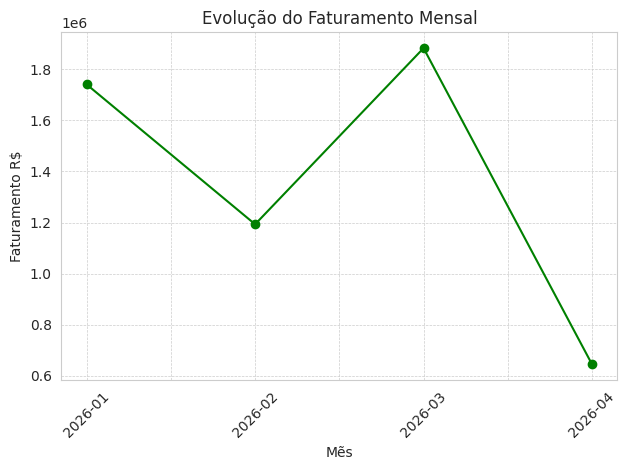

In [29]:
# define o tamanho da figura do grafico
plt.Figure(figsize=(1, 1))

# plota os dados de faturaento mensal em formato de linha
faturamento_mensal.plot(kind="line", marker="o", linestyle="-", color="green")

# define o titulo do grafico
plt.title("Evolução do Faturamento Mensal", fontsize=12)

# define o rotulo do eixo x
plt.xlabel("Mẽs", fontsize=10)

# define o rotulo do eixo y
plt.ylabel("Faturamento R$", fontsize=10)

# rotaciona o rotulo do eixo x para melhor visualizacao
plt.xticks(rotation=45)

# adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

# ajusta automaticamente os elementos para evitar sobreposicao
plt.tight_layout()

# exibe o grafico
plt.show()

## 8. Análise 03 - Faturamento por Estado
Qual o faturamento total por estado?

In [30]:
# agrupa por estado e soma o faturamento
faturamento_por_estado = df_vendas.groupby("estado")["faturamento"].sum().sort_values(ascending = False)

In [31]:
# formata para duas casas decimais
faturamento_por_estado.map('R$ {:,.2f}'.format)

estado
MG    R$ 1,090,412.65
SP      R$ 997,210.33
BA      R$ 790,163.76
PR      R$ 708,810.92
RS      R$ 644,341.10
CE      R$ 625,690.01
RJ      R$ 605,174.77
Name: faturamento, dtype: str

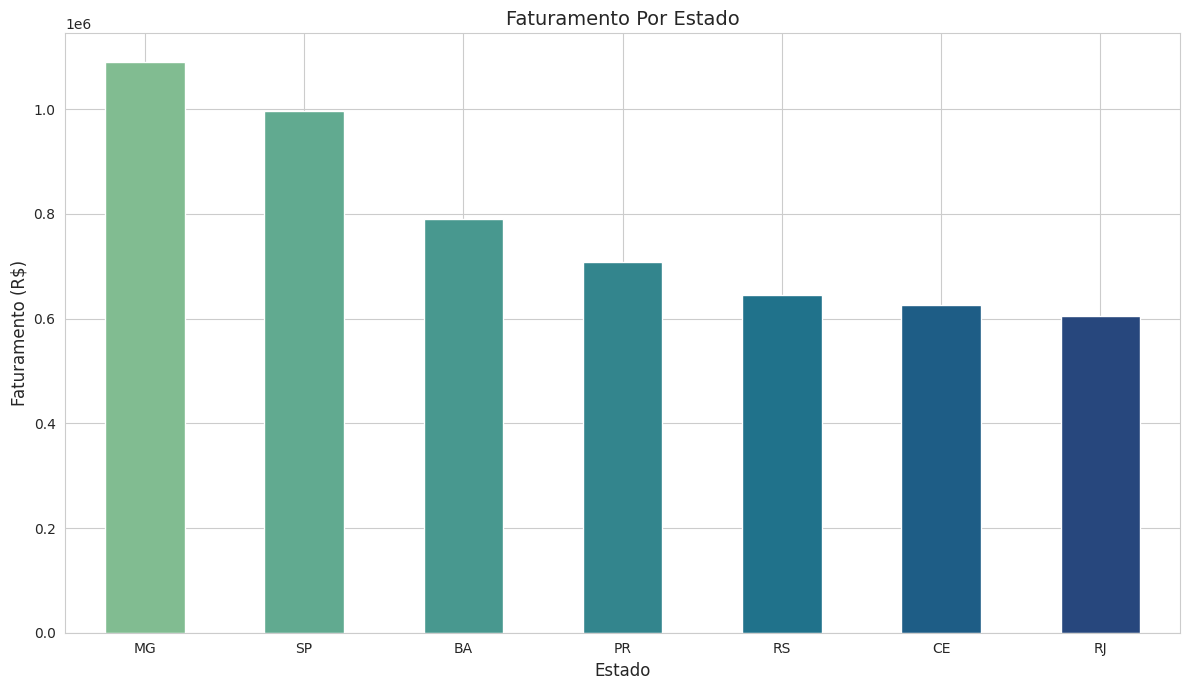

In [32]:
# define uma nova figura
plt.figure(figsize = (12, 7))

# plota os dados de faturamento por estado em formato de gráfico de barras
# usando a paleta de cores "rocket" do Seaborn
faturamento_por_estado.plot(kind = 'bar', color = sns.color_palette("crest", 7))

# define o titulo do do grafico
plt.title('Faturamento Por Estado', fontsize = 14)

# define o rotulo do eixo x
plt.xlabel('Estado', fontsize = 12)

# define o rotulo do eixo y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# mante o rotulo do eixo x na horizontal (sem rotacao)
plt.xticks(rotation = 0)

# ajusta autoaticaente os elementos do grafico para evitar sobreposicao
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 9. Análise 04 - Faturamento por Categoria
Qual o faturamento total por categoria?

In [33]:
# agrupa por categoria e soma o faturamento
faturamento_por_categoria = df_vendas.groupby("categoria")["faturamento"].sum().sort_values(ascending = False)

In [34]:
# formata para duas casas decimais
faturamento_por_categoria.map('R$ {:,.2f}'.format)

categoria
Eletrônicos    R$ 3,540,700.00
Hardware       R$ 1,232,100.00
Acessórios       R$ 425,003.54
Móveis           R$ 264,000.00
Name: faturamento, dtype: str

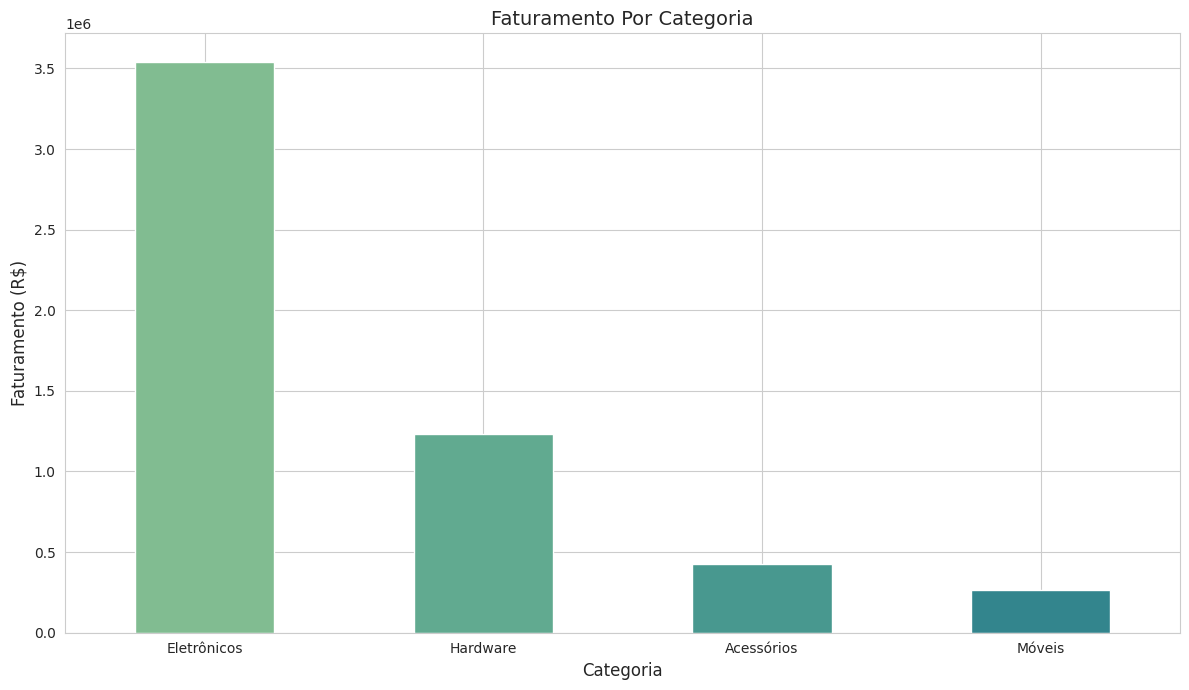

In [35]:
# define uma nova figura
plt.figure(figsize = (12, 7))

# plota os dados de faturamento por cartegoria em formato de grafico de barras
faturamento_por_categoria.plot(kind = 'bar', color = sns.color_palette("crest", 7))

# define o titulo do do grafico
plt.title('Faturamento Por Categoria', fontsize = 14)

# define o rotulo do eixo x
plt.xlabel('Categoria', fontsize = 12)

# define o rotulo do eixo y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# mantem o rotulo do eixo x na horizontal (sem rotacao)
plt.xticks(rotation = 0)

# ajusta autoaticaente os elementos do grafico para evitar sobreposicao
plt.tight_layout()

# Exibe o gráfico
plt.show()

## 10. Conclusão e Entrega do Resultado

A análise dos 500 pedidos registrados entre janeiro e abril de 2026 permitiu identificar padrões relevantes de desempenho comercial, faturamento e distribuição geográfica das vendas. O faturamento total do período foi de R$ 5.334.629,80, com ticket médio de R$ 10.669,26 por pedido.

Em termos de volume vendido, os produtos com maior destaque foram Placa de Vídeo, SSD 1TB, Teclado Mecânico, Laptop Gamer e Monitor Ultrawide. Contudo, sob a perspectiva de faturamento, Laptop Gamer, Placa de Vídeo e Monitor Ultrawide concentraram a maior parcela da receita, evidenciando que os itens de maior valor unitário exercem papel estratégico no resultado do negócio.

Na análise por categoria, Eletrônicos liderou com 54,83% do faturamento total, seguida por Hardware com 33,07%. Isso demonstra forte concentração da receita em categorias de maior valor agregado. Na dimensão geográfica, o Rio Grande do Sul apresentou o melhor desempenho em faturamento, seguido por Ceará e São Paulo, indicando mercados prioritários para ações comerciais e logísticas.

No recorte temporal, janeiro e março apresentaram os melhores resultados de faturamento no período analisado. Abril registrou valor inferior, mas deve ser interpretado com cautela, pois representa um mês incompleto na base de dados.

Como encaminhamento estratégico, recomenda-se priorizar o abastecimento e a promoção dos produtos de maior faturamento, estruturar campanhas segmentadas por estado e categoria, e aprofundar análises futuras com indicadores como margem de lucro, custo de frete, recompra e sazonalidade em uma janela maior de tempo.

Conclui-se que a análise de dados cumpre papel central na transformação de informações operacionais em decisões de negócio mais precisas. Mesmo com uma base fictícia, o projeto demonstrou como as etapas de limpeza, preparação, exploração e visualização de dados podem apoiar a gestão de estoque, o marketing e a expansão comercial com base em evidências.